PHASE 1 : Data Understanding

Goal:
Understand the data before analysis.

Importing Libraries

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score  ,classification_report

- Loading Dataset 
- Checking null values and blank cells in dataset

In [36]:
dataset = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv",na_values=["", " "])

Getting shape of the dataset

In [37]:
dataset.shape

(7043, 21)

Column Names


In [62]:
dataset.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Checking null values in loaded dataset

In [38]:
dataset.isnull().sum()


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Cleaning dataset by droping the rows in which the values are null

In [39]:
clean_dataset = dataset.dropna(subset=['TotalCharges'])

Result Clean Dataset

In [40]:
clean_dataset.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Checking datatypes of dataset

In [41]:
clean_dataset.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Extracting only Number data column in dataset

In [42]:
clean_dataset.select_dtypes(include=['number'])


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65
...,...,...,...,...
7038,0,24,84.80,1990.50
7039,0,72,103.20,7362.90
7040,0,11,29.60,346.45
7041,1,4,74.40,306.60


Extracting all columns except number data in dataset

In [43]:
clean_dataset.select_dtypes(exclude=['number'])

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,No
7039,2234-XADUH,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),No
7040,4801-JZAZL,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
7041,8361-LTMKD,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,Yes


Checking duplicates values

In [44]:
display(f"The duplicate values in {clean_dataset.duplicated().sum()}")

display(f"The duplicates values in CustomerID column is {clean_dataset.duplicated("customerID").sum()}")

'The duplicate values in 0'

'The duplicates values in CustomerID column is 0'

Generating Summary statistics in numerical columns

In [45]:
clean_dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


*PHASE 2: Exploratory Data Analysis (EDA)*

Goal
Find customer behavior patterns.

Getting values count in the main column

In [46]:
count=clean_dataset['Churn'].value_counts()
print("The churn column values cout as:",count)

The churn column values cout as: Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [47]:
count_percentage = clean_dataset['Churn'].value_counts(normalize='True')*100
print(f"Churn Percentage: {count_percentage}")

Churn Percentage: Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


Do long-term customers churn less?

In [48]:
#Filtering.
had_churned = clean_dataset[clean_dataset['Churn']=='Yes']
not_churned = clean_dataset[clean_dataset['Churn']=='No']

#getting average_tenure with respect to churn
average_tenure_yes = had_churned[had_churned['Churn']=='Yes']['tenure'].mean()
average_tenure_no = not_churned[not_churned['Churn']=='No']['tenure'].mean()
display(f'The average of churned customer are : {average_tenure_yes:.2f}%')
display(f'The average of non churned customer are: {average_tenure_no:.2f}%')
#getting max and min tenure ratio of customer who churned and not
max_tenure_yes = had_churned[had_churned['Churn']=='Yes']['tenure'].max()
min_tenure_no = not_churned[not_churned['Churn']=='No']['tenure'].min()
display(f'The maximum of churned customer are : {max_tenure_yes:.2f}%')
display(f'The minimum of non churned customer are: {min_tenure_no:.2f}%')


'The average of churned customer are : 17.98%'

'The average of non churned customer are: 37.65%'

'The maximum of churned customer are : 72.00%'

'The minimum of non churned customer are: 1.00%'

Do expensive plans churn more?

In [49]:
clean_dataset[['Churn' , 'MonthlyCharges']]

,Churn,MonthlyCharges
0,No,29.85
1,No,56.95
2,Yes,53.85
3,No,42.30
4,Yes,70.70
...,...,...
7038,No,84.80
7039,No,103.20
7040,No,29.60
7041,Yes,74.40


Do expensive plans churn more?

In [50]:
mean_monthlycharges_yes = had_churned[had_churned['Churn']=='Yes']['MonthlyCharges'].mean()
mean_montlycharges_no = not_churned[not_churned['Churn']=='No']['MonthlyCharges'].mean()
display(f'The customer which churned due to charges: {mean_monthlycharges_yes:.2f}%')
display(f'The customer which no-churned due to charges: {mean_montlycharges_no:.2f}%')

'The customer which churned due to charges: 74.44%'

'The customer which no-churned due to charges: 61.31%'

Which contract type causes highest churn?

In [51]:
total_custo = clean_dataset['Contract'].value_counts()
churned_cust=had_churned['Contract'].value_counts()
display(churned_cust)
display(total_custo)
#printing percentage for Churned customer for each contract entity
churn_percentages = pd.crosstab(clean_dataset['Contract'], clean_dataset['Churn'], normalize='index') * 100
print(churn_percentages)




Contract
Month-to-month    1655
One year           166
Two year            48
Name: count, dtype: int64

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


Phase 3 : Visualization

Churn Distribution

Question:
How many customers churn?

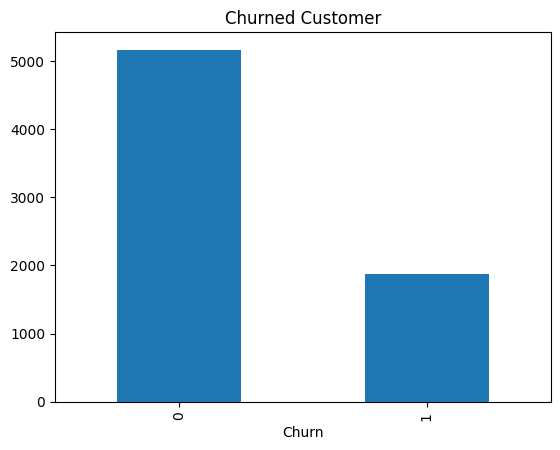

In [112]:
clean_dataset['Churn'].value_counts().plot(kind='bar')
plt.title("Churned Customer")
plt.savefig('Churned Customer.png', bbox_inches='tight')
plt.show()

Revenue Distribution

Question:

Where does revenue come from?

In [53]:
clean_dataset[['MonthlyCharges','TotalCharges']].describe()

,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000
mean,64.798208,2283.300441
std,30.085974,2266.771362
min,18.250000,18.800000
25%,35.587500,401.450000
50%,70.350000,1397.475000
75%,89.862500,3794.737500
max,118.750000,8684.800000


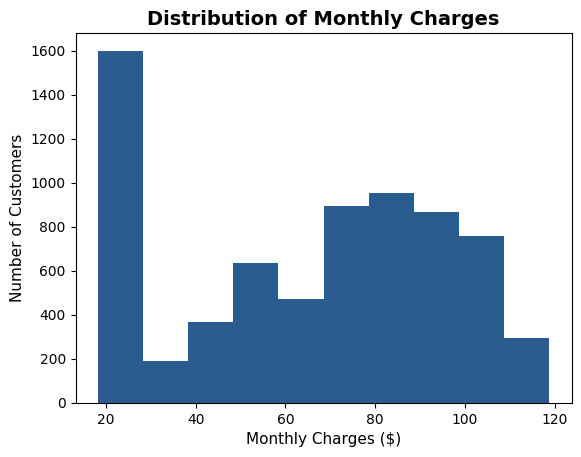

In [111]:
# Plotting with custom styling
plt.hist(clean_dataset['MonthlyCharges'], color='#2b5c8f')

# Adding structure and clarity
plt.title('Distribution of Monthly Charges', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges ($)', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.savefig('Distribution of Monthly Charges.png', bbox_inches='tight')
plt.show()

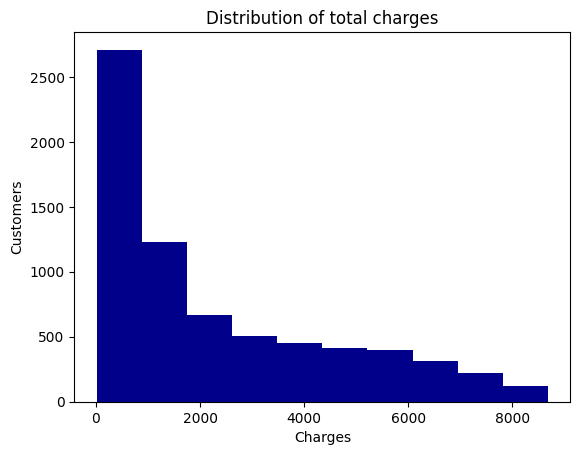

In [110]:
plt.hist(clean_dataset['TotalCharges'],color='darkblue')

plt.title('Distribution of total charges')
plt.xlabel('Charges')
plt.ylabel('Customers')
plt.savefig('Distribution of total charges.png', bbox_inches='tight')
plt.show()

Results : Most customers generate relatively low revenue, while a smaller number of customers contribute significantly higher revenue.

Visualization 3

Customer Segmentation Chart

- High value

- Medium value

- Low value

In [56]:
def assign_value_segment(total_charges):
    if total_charges <= 401.45:
        return 'Low Value'
    elif total_charges <= 3794.74:
        return 'Medium Value'
    else:
        return 'High Value'

clean_dataset['CustomerSegment'] = clean_dataset['TotalCharges'].apply(assign_value_segment)

clean_dataset[['TotalCharges', 'CustomerSegment']].head(3)

C:\Users\HP\AppData\Local\Temp\ipykernel_16504\4074243602.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_dataset['CustomerSegment'] = clean_dataset['TotalCharges'].apply(assign_value_segment)


,TotalCharges,CustomerSegment
0,29.85,Low Value
1,1889.50,Medium Value
2,108.15,Low Value


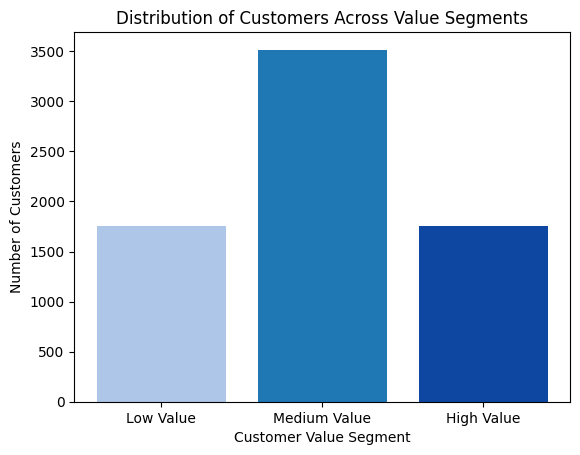

In [109]:
segments = ['Low Value', 'Medium Value', 'High Value']
counts = [1758, 3516, 1758]
colors = ['#aec7e8', '#1f77b4', '#0d47a1']

plt.bar(segments, counts, color=colors)

plt.xlabel('Customer Value Segment')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customers Across Value Segments')
plt.savefig('Distribution of Customer Across Value Segment.png', bbox_inches='tight')
plt.show()

Correlation heatmap 

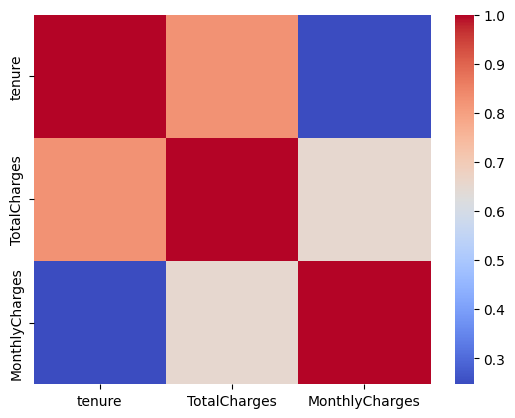

In [108]:
sns.heatmap(clean_dataset[['tenure','TotalCharges','MonthlyCharges']].corr() , cmap='coolwarm')
plt.savefig('Correlation Heatmap.png', bbox_inches='tight')
plt.show()



Comparison of Two Columns (Tenure , Churn)

C:\Users\HP\AppData\Local\Temp\ipykernel_16504\2811485157.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_dataset['tenuregroup'] = pd.cut(clean_dataset['tenure'],bins=bins, labels=labels)
C:\Users\HP\AppData\Local\Temp\ipykernel_16504\2811485157.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data = clean_dataset.groupby(['tenuregroup','Churn']).size().unstack(fill_value=0)


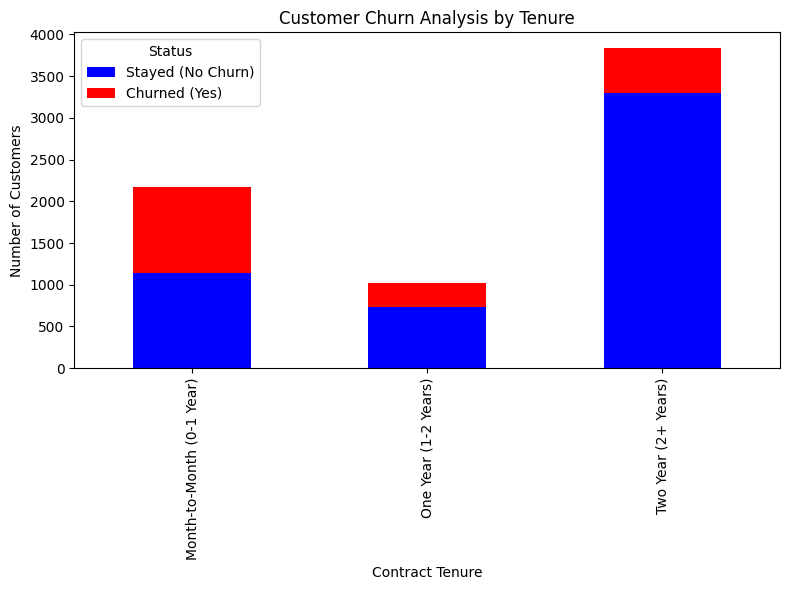

In [107]:
bins = [0, 12, 24, 72]
labels = ['Month-to-Month (0-1 Year)', 'One Year (1-2 Years)', 'Two Year (2+ Years)']
clean_dataset['tenuregroup'] = pd.cut(clean_dataset['tenure'],bins=bins, labels=labels)
plot_data = clean_dataset.groupby(['tenuregroup','Churn']).size().unstack(fill_value=0)
plot_data.plot(kind='bar',stacked='True' , color =['blue','red'], figsize = (8,6))
plt.title('Customer Churn Analysis by Tenure')
plt.xlabel('Contract Tenure')
plt.ylabel('Number of Customers')
plt.legend(['Stayed (No Churn)', 'Churned (Yes)'], title='Status')
plt.tight_layout()
plt.savefig('comparsion_bar_chart(Tenure vs Churn).png', bbox_inches='tight')
plt.show()

Comparison graph for PaymentMethod vs Churn

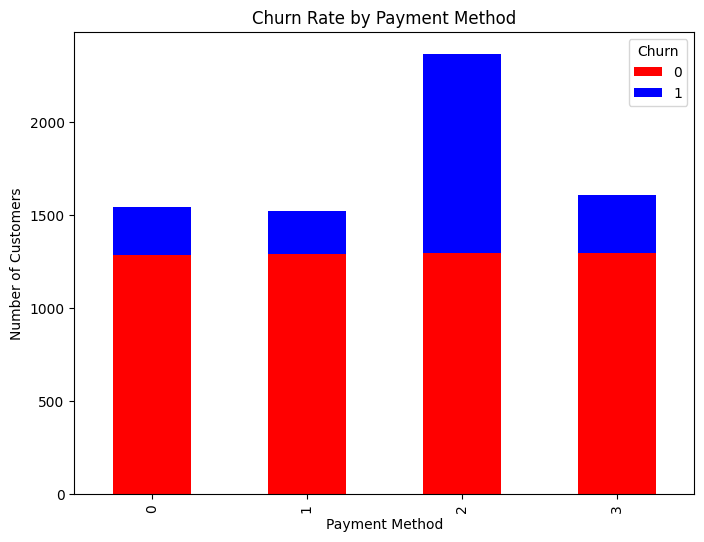

In [106]:
plot_data = clean_dataset.groupby(['PaymentMethod','Churn']).size().unstack(fill_value = 0)
plot_data.plot(kind='bar',stacked = 'True' , color = ('red','blue'), figsize = (8,6))
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.savefig('comparsion_bar_chart(PaymentMethod vs Churn).png', bbox_inches='tight')
plt.show()

Trainning a model 
- Logistic regression.

In [ ]:
from sklearn.preprocessing import LabelEncoder
feature_columns=['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
target_columns='Churn'

categorical_col = clean_dataset.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_col:
       clean_dataset[col]=le.fit_transform(clean_dataset[col])

x = clean_dataset[feature_columns]
y = clean_dataset[target_columns]

x_train , x_test , y_train, y_test = train_test_split(x,y,test_size=0.2 , random_state=42)
log_model = LogisticRegression()



In [101]:
log_model.fit(x_train , y_train)
log_model_prediction = log_model.predict(x_test)
log_model_accuracy = accuracy_score(y_test , log_model_prediction)
print("Logistic regression")
print(f"Accuracy:{log_model_accuracy*100:.2f}%")
print(classification_report(y_test, log_model_prediction))



Logistic regression
Accuracy:78.75%
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Random forest Classification model

In [105]:
from sklearn.ensemble import RandomForestClassifier
rand_model = RandomForestClassifier()
rand_model.fit(x_train, y_train)
rand_model_prediction = rand_model.predict(x_test)
rand_accuracy = accuracy_score(y_test , rand_model_prediction)
print("Random Model Classification")
print(f"Accuracy report: {rand_accuracy*100:.2f}%")
print(classification_report(y_test, rand_model_prediction))

Random Model Classification
Accuracy report: 78.82%
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.78      1407



- Basic Prediction System

In [116]:
def predict_churn_risk(churn_probability):
    if not (0 <=churn_probability <=1):
        return "Invalid probability. Must be between 0 and 1"
    if churn_probability < 0.30:
        risk_category = "Low Risk"
        recommended_action = 'Maintain standard engagment'
    elif churn_probability <=0.70:
        risk_category = "Medium Risk"
        recommended_action = "Deploy Targeted promotional campagins"
    else:
        risk_category ='High Risk'
        recommended_action = 'Initiate immediate high priority  protocols'
    return { 
        "Churn probability":f"{churn_probability*100:.2f}%",
        "Risk Category" : risk_category,
        "Action Plan" : recommended_action
    }

sample_customers = [0.15,0.52,0.88]
print("Execution Churn Risk analysis")
for prob in sample_customers:
    result = predict_churn_risk(prob)
    print(f"Customer Ananlysis:{result}")

Execution Churn Risk analysis
Customer Ananlysis:{'Churn probability': '15.00%', 'Risk Category': 'Low Risk', 'Action Plan': 'Maintain standard engagment'}
Customer Ananlysis:{'Churn probability': '52.00%', 'Risk Category': 'Medium Risk', 'Action Plan': 'Deploy Targeted promotional campagins'}
Customer Ananlysis:{'Churn probability': '88.00%', 'Risk Category': 'High Risk', 'Action Plan': 'Initiate immediate high priority  protocols'}


Business Insights Report 
- Top churn reasons 
- High-risk customer traits 
- Revenue impact estimation 

In [121]:
average_dataset = clean_dataset.groupby('Churn')['MonthlyCharges'].mean()
display(average_dataset)

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

Results : Customers who churned had an average monthly charge of $74.44, compared to $61.31 for customers who remained with the company. This suggests that higher monthly charges may contribute to increased customer churn.